# <center>**Linear Regression**</center>

## Algorithms

1. **Closed form**

2. **Gradient descent**

3. **Stochastic gradient descent**

4. **Mini batch**


---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from linear_regression import Linear_Regression
from metrics import MSE, RMSE

# importing dataset
path = '../data/happiness2016.csv'

df = pd.read_csv(path)

#### Checking data

In [2]:
df.head()

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        157 non-null    str    
 1   Region                         157 non-null    str    
 2   Happiness Rank                 157 non-null    int64  
 3   Happiness Score                157 non-null    float64
 4   Lower Confidence Interval      157 non-null    float64
 5   Upper Confidence Interval      157 non-null    float64
 6   Economy (GDP per Capita)       157 non-null    float64
 7   Family                         157 non-null    float64
 8   Health (Life Expectancy)       157 non-null    float64
 9   Freedom                        157 non-null    float64
 10  Trust (Government Corruption)  157 non-null    float64
 11  Generosity                     157 non-null    float64
 12  Dystopia Residual              157 non-null    float64
dtypes

#### Dataset Description

Dataset represents factors that have more or less influence on people's happiness in 157 countries in 2015. Each row corresponds to one country.

* **Country** – country name
* **Region** – region of the country
* **Happiness Rank** – country's rank according to the happiness score
* **Happiness Score** – average happiness score (0–10)
* **Lower Confidence Interval** – lower bound of the confidence interval for the happiness score
* **Upper Confidence Interval** – upper bound of the confidence interval for the happiness score
* **Economy (GDP per Capita)** – GDP contribution to the happiness score
* **Family** – family support contribution to the score
* **Health (Life Expectancy)** – life expectancy contribution to the score
* **Freedom** – feeling of freedom contribution to the score
* **Trust (Government Corruption)** – perception of corruption contribution to the score
* **Generosity** – generosity contribution to the score
* **Dystopia Residual** – difference between predicted and observed happiness not explained by other factors

#### Visualizing data

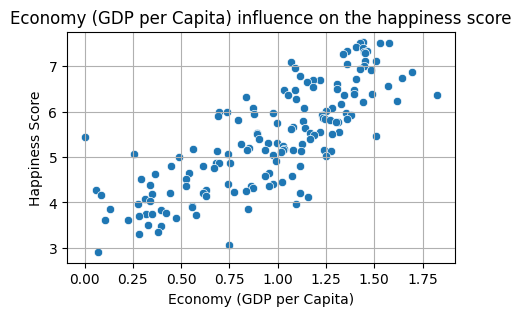

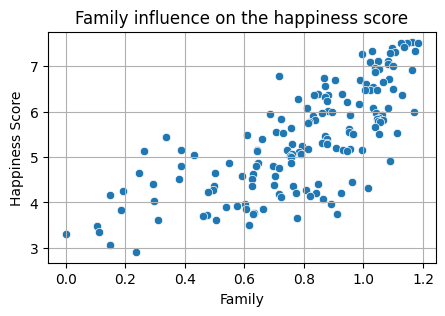

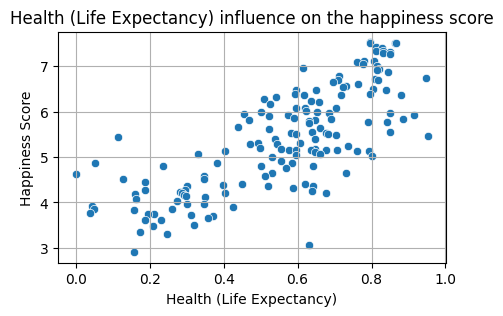

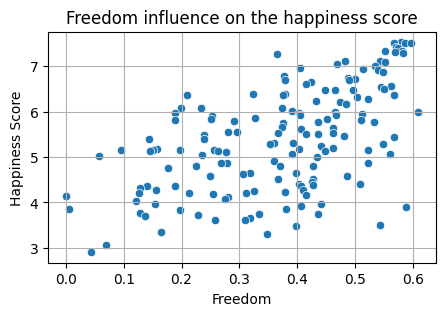

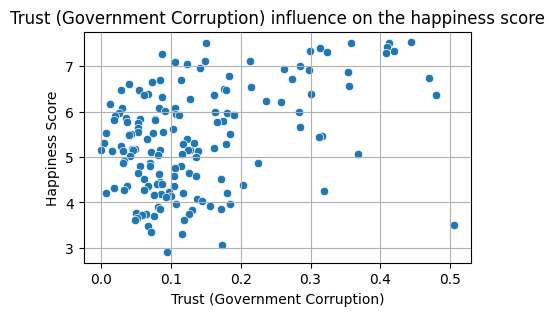

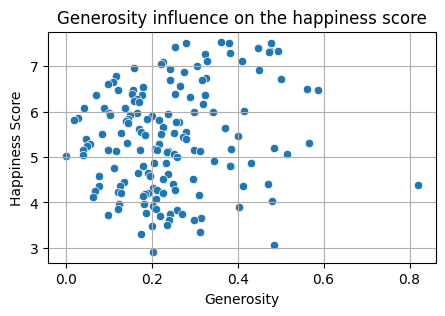

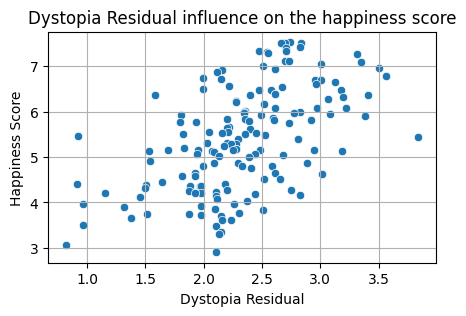

In [4]:
features = [
    'Economy (GDP per Capita)',
    'Family', 
    'Health (Life Expectancy)', 
    'Freedom',
    'Trust (Government Corruption)', 
    'Generosity',
    'Dystopia Residual'
]

for feature in features:
    plt.figure(figsize=(5, 3))
    sns.scatterplot(data=df, x=feature, y='Happiness Score')
    plt.grid(True)
    plt.title(f'{feature} influence on the happiness score')
    plt.show()

---

### **Closed form**

Error:
0.6972626334828966
Final function:
y = [2.18686322]X + 3.296180041308007
Error:
0.00029323944326990363
Final function:
y = [0.99999088 1.00002422 0.99985263 1.00016829 0.99970066 1.00017439
 0.99994759]X + 0.0001357357434505694


Text(0, 0.5, 'Happiness Score')

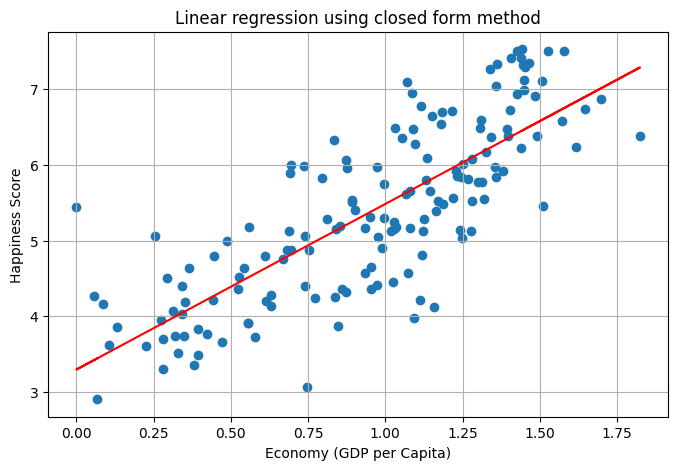

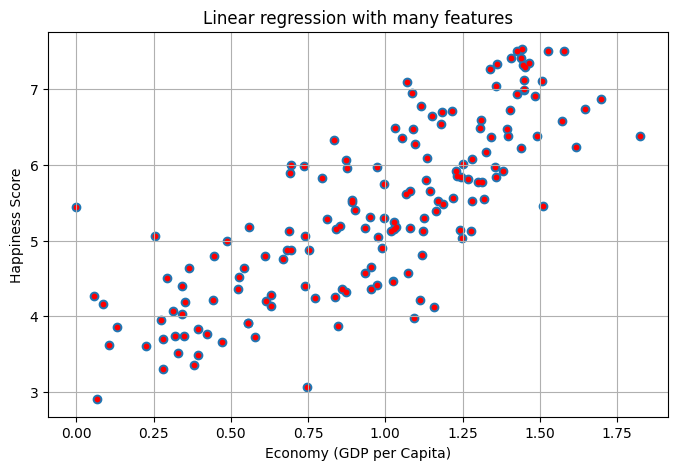

In [5]:
from closed_form import Linear_Regression_Closed_Form

X = df['Economy (GDP per Capita)'].to_numpy()
y = df['Happiness Score'].to_numpy()

closed_form = Linear_Regression_Closed_Form()
closed_form.fit(X, y)

y_pred = closed_form.predict(X)

print(f'Error:\n{RMSE(y, y_pred)}')
print(f'Final function:\ny = {closed_form.weights}X + {closed_form.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Closed form')
plt.grid(True)
plt.title('Linear regression using closed form method')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')

X = df[features].to_numpy()
y = df['Happiness Score'].to_numpy()

closed_form = Linear_Regression_Closed_Form()
closed_form.fit(X, y)

y_pred = closed_form.predict(X)

print(f'Error:\n{RMSE(y, y_pred)}')
print(f'Final function:\ny = {closed_form.weights}X + {closed_form.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], y, label='Data')
plt.scatter(X[:, 0], y_pred, color='red', s=10, label='Prediction')
plt.grid(True)
plt.title('Linear regression with many features')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')

---

### **Gradient descent**

RMSE: [5.27981017]
RMSE: [1.92089973]
RMSE: [0.97226179]
RMSE: [0.79603872]
RMSE: [0.77338637]
RMSE: [0.77065284]
RMSE: [0.7702249]
RMSE: [0.7700631]
RMSE: [0.76993532]
RMSE: [0.76981509]
RMSE: [0.76969927]
RMSE: [0.76958739]
RMSE: [0.76947929]
RMSE: [0.76937483]
RMSE: [0.76927388]
RMSE: [0.76917634]
RMSE: [0.76908208]
RMSE: [0.768991]
RMSE: [0.76890299]
RMSE: [0.76881795]
RMSE: [0.76873577]
RMSE: [0.76865637]
RMSE: [0.76857964]
RMSE: [0.7685055]
RMSE: [0.76843386]
RMSE: [0.76836463]
RMSE: [0.76829774]
RMSE: [0.76823311]
RMSE: [0.76817065]
RMSE: [0.76811031]
RMSE: [0.768052]
RMSE: [0.76799565]
RMSE: [0.76794121]
RMSE: [0.76788861]
RMSE: [0.76783778]
RMSE: [0.76778867]
RMSE: [0.76774121]
RMSE: [0.76769536]
RMSE: [0.76765105]
RMSE: [0.76760824]
RMSE: [0.76756688]
RMSE: [0.76752691]
RMSE: [0.76748829]
RMSE: [0.76745098]
RMSE: [0.76741492]
RMSE: [0.76738009]
RMSE: [0.76734643]
RMSE: [0.7673139]
RMSE: [0.76728248]
RMSE: [0.76725211]
RMSE: [0.76722278]
RMSE: [0.76719443]
RMSE: [0.76716704]
R

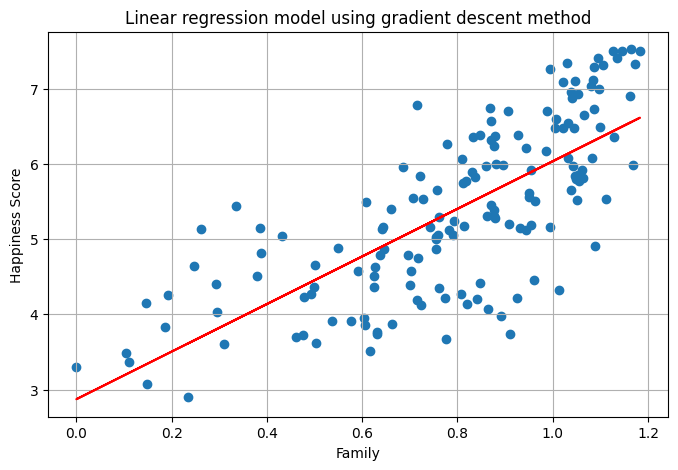

In [6]:
from gradient_descent import Linear_Regression_Gradient

X = df['Family'].to_numpy()
y = df['Happiness Score'].to_numpy()

gradient_descent = Linear_Regression_Gradient()

gradient_descent.fit(X, y, max_iters=1000, lr=0.2, stats=True)
y_pred = gradient_descent.predict(X)

print(f'Final function:\ny = {gradient_descent.weights}x + {gradient_descent.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Gradient descent')
plt.xlabel('Family')
plt.ylabel('Happiness Score')
plt.title('Linear regression model using gradient descent method')
plt.grid()

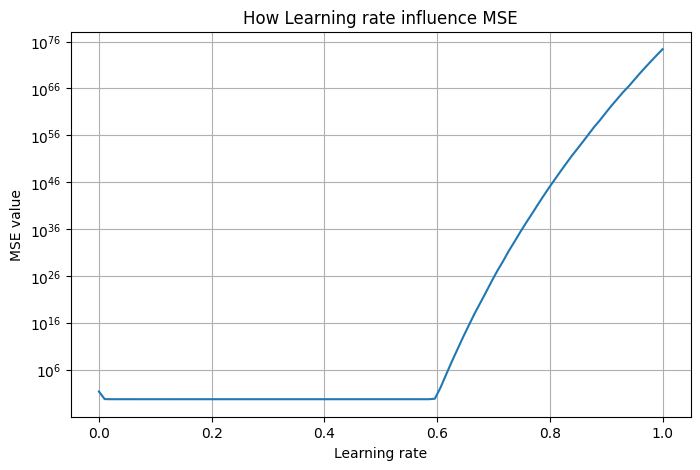

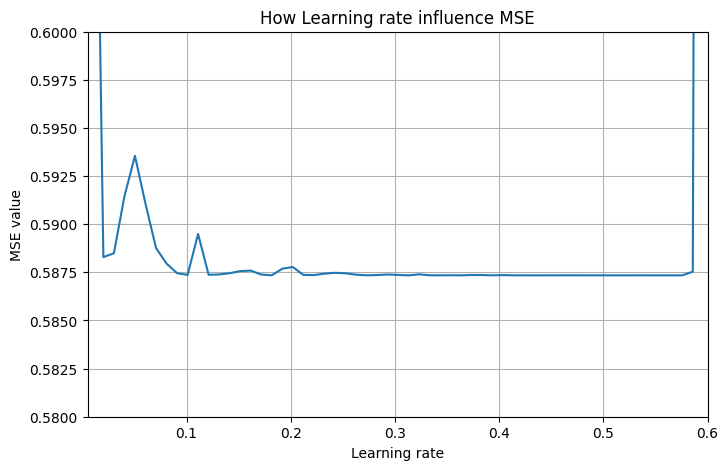

In [7]:
# === Learning rate test ===
learning_rate = np.linspace(0, 1, 100)
errors = []

for alpha in learning_rate:
    lr_test = Linear_Regression_Gradient()
    gradient_descent.fit(X, y, max_iters=100, lr=alpha, stats=False)
    y_pred = gradient_descent.predict(X)

    errors.append(MSE(y, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.yscale('log')
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE')
plt.grid()

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.xlim(0.005, 0.6)
plt.ylim(0.58, 0.6)
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE')
plt.grid()


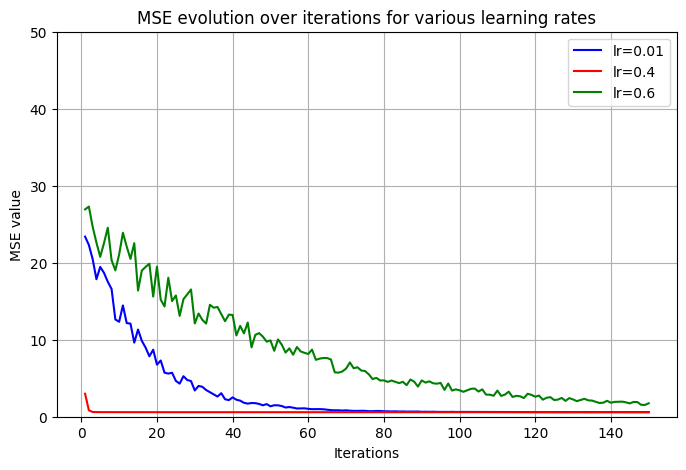

In [8]:
# === Iteration test ===
iterations = np.linspace(1, 150, 150, dtype=int)
learning_rate = [0.01, 0.4, 0.6]

errors = []
for alpha in learning_rate:
    error = []
    for iter in iterations:
        iter_test = Linear_Regression_Gradient()
        gradient_descent.fit(X, y, max_iters=iter, lr=alpha, stats=False)
        y_pred = gradient_descent.predict(X)

        error.append(MSE(y, y_pred))
    errors.append(error)


plt.figure(figsize=(8, 5))
plt.plot(iterations, errors[0], color='blue', label='lr=0.01')
plt.plot(iterations, errors[1], color='red', label='lr=0.4')
plt.plot(iterations, errors[2], color ='green', label='lr=0.6')
plt.ylim(0, 50)
plt.xlabel('Iterations')
plt.ylabel('MSE value')
plt.title('MSE evolution over iterations for various learning rates')
plt.legend()
plt.grid()


---

### **Stochastic gradient descent**

RMSE: [0.08417233]
RMSE: [1.05466312]
RMSE: [0.97978325]
RMSE: [1.34654291]
RMSE: [0.43681983]
RMSE: [0.09740808]
RMSE: [0.89766876]
RMSE: [0.19161512]
RMSE: [0.19320901]
RMSE: [0.20585172]
RMSE: [0.51308382]
RMSE: [0.23189994]
RMSE: [0.5752002]
RMSE: [1.33526145]
RMSE: [0.72547534]
RMSE: [0.09696542]
RMSE: [1.07236592]
RMSE: [0.61833465]
RMSE: [0.74154529]
RMSE: [0.3490159]
RMSE: [0.14602614]
RMSE: [0.54090718]
RMSE: [0.59452229]
RMSE: [0.62070394]
RMSE: [0.16725492]
RMSE: [0.70682028]
RMSE: [0.60192075]
RMSE: [0.02020468]
RMSE: [0.68891092]
RMSE: [0.07702848]
RMSE: [1.08007534]
RMSE: [0.1674831]
RMSE: [1.48822503]
RMSE: [0.73488628]
RMSE: [0.42034112]
RMSE: [0.63763998]
RMSE: [0.18007063]
RMSE: [2.71569587]
RMSE: [0.46677864]
RMSE: [0.84369013]
RMSE: [1.02308127]
RMSE: [1.1607906]
RMSE: [1.1977342]
RMSE: [1.32677319]
RMSE: [0.32719064]
RMSE: [0.80762643]
RMSE: [0.3167462]
RMSE: [0.467116]
RMSE: [0.19299745]
RMSE: [0.91955464]
RMSE: [0.93075729]
RMSE: [0.65342738]
RMSE: [0.46675783]
R

Text(0.5, 1.0, 'Linear regression model using stochastic gradient descent method')

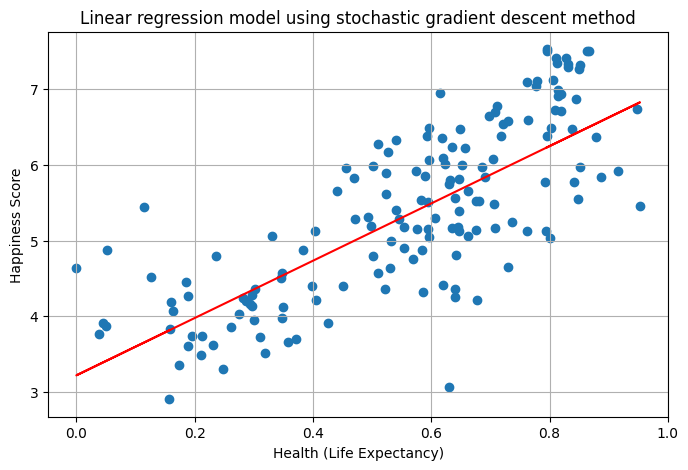

In [34]:
from stochastic_gd import Linear_Regression_Stochastic_GD

X = df['Health (Life Expectancy)'].to_numpy()
y = df['Happiness Score'].to_numpy()

stochastic = Linear_Regression_Stochastic_GD()
stochastic.fit(X, y, max_iters=100, lr=0.02, stats=True)

y_pred = stochastic.predict(X)

print(f'Final function\ny = {stochastic.weights}x + {stochastic.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Stochastic gradient descent')
plt.grid()
plt.xlabel('Health (Life Expectancy)')
plt.ylabel('Happiness Score')
plt.title('Linear regression model using stochastic gradient descent method')

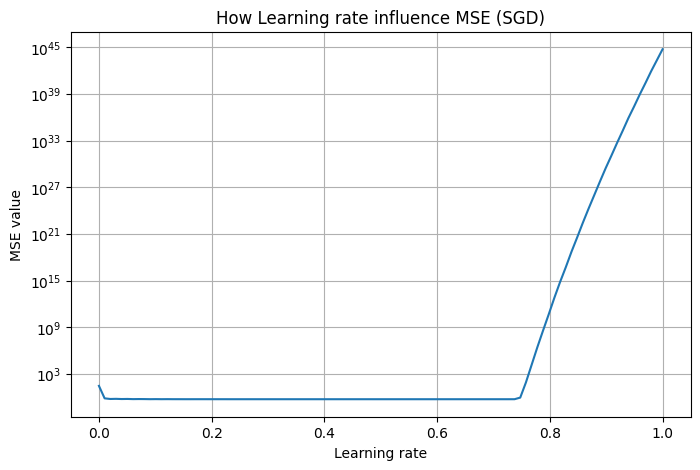

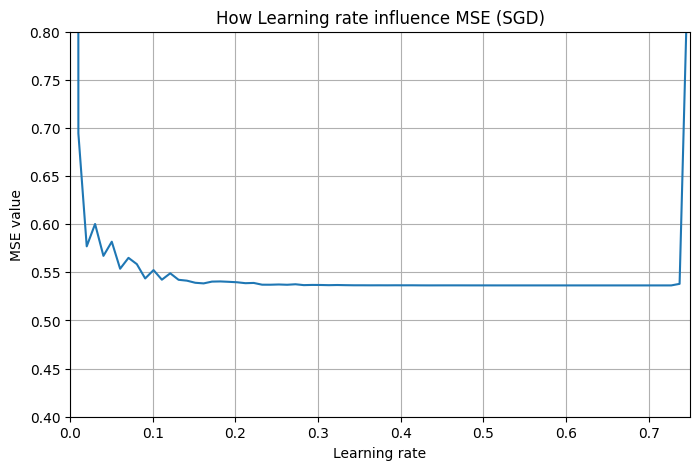

In [10]:
# === Learning rate test ===
learning_rate = np.linspace(0, 1, 100)
errors = []

for alpha in learning_rate:
    lr_test = Linear_Regression_Stochastic_GD()
    gradient_descent.fit(X, y, max_iters=100, lr=alpha, stats=False)
    y_pred = gradient_descent.predict(X)

    errors.append(MSE(y, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.yscale('log')
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE (SGD)')
plt.grid()

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.xlim(0, 0.75)
plt.ylim(0.4, 0.8)
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE (SGD)')
plt.grid()

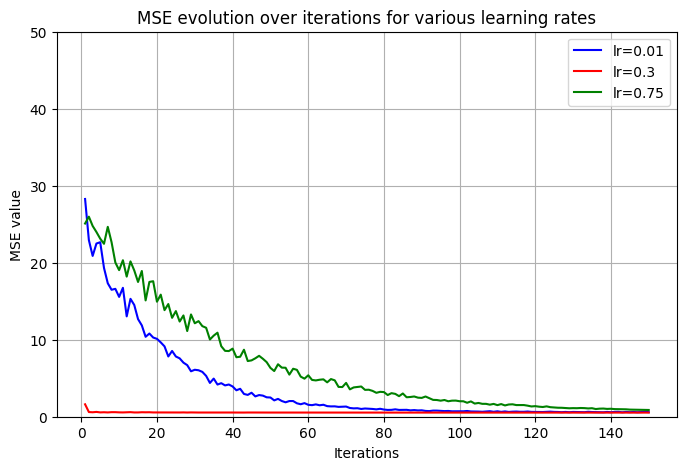

In [11]:
# === Iteration test ===
iterations = np.linspace(1, 150, 150, dtype=int)
learning_rate = [0.01, 0.3, 0.75]

errors = []
for alpha in learning_rate:
    error = []
    for iter in iterations:
        iter_test = Linear_Regression_Stochastic_GD()
        gradient_descent.fit(X, y, max_iters=iter, lr=alpha, stats=False)
        y_pred = gradient_descent.predict(X)

        error.append(MSE(y, y_pred))
    errors.append(error)


plt.figure(figsize=(8, 5))
plt.plot(iterations, errors[0], color='blue', label=f'lr={learning_rate[0]}')
plt.plot(iterations, errors[1], color='red', label=f'lr={learning_rate[1]}')
plt.plot(iterations, errors[2], color ='green', label=f'lr={learning_rate[2]}')
plt.ylim(0, 50)
plt.xlabel('Iterations')
plt.ylabel('MSE value')
plt.title('MSE evolution over iterations for various learning rates')
plt.legend()
plt.grid()


---

### **Mini batch**

RMSE: [1.09712664]
RMSE: [1.1167296]
RMSE: [0.90900549]
RMSE: [0.92125385]
RMSE: [1.0599154]
RMSE: [1.04584895]
RMSE: [1.10768369]
RMSE: [1.10595675]
RMSE: [1.01523042]
RMSE: [1.03737003]
RMSE: [1.08996926]
RMSE: [1.01003407]
RMSE: [0.94074295]
RMSE: [1.0314152]
RMSE: [1.01756993]
RMSE: [0.91823724]
RMSE: [0.88681228]
RMSE: [1.09032824]
RMSE: [0.93514466]
RMSE: [0.89301959]
RMSE: [1.0192426]
RMSE: [0.9085745]
RMSE: [0.93241377]
RMSE: [1.12718364]
RMSE: [0.90873726]
RMSE: [0.93131908]
RMSE: [0.91896701]
RMSE: [1.04466575]
RMSE: [0.99637054]
RMSE: [0.970166]
RMSE: [0.8819291]
RMSE: [1.13710324]
RMSE: [0.884103]
RMSE: [0.99399402]
RMSE: [0.842783]
RMSE: [0.91399707]
RMSE: [0.95395305]
RMSE: [0.94534553]
RMSE: [1.0219167]
RMSE: [0.95216469]
RMSE: [0.9327529]
RMSE: [0.98416096]
RMSE: [1.06354566]
RMSE: [1.03251543]
RMSE: [0.89028352]
RMSE: [0.92654056]
RMSE: [0.85996395]
RMSE: [0.98578906]
RMSE: [0.91893558]
RMSE: [1.1492431]
RMSE: [0.9460872]
RMSE: [0.86203057]
RMSE: [0.93899661]
RMSE: [0.

Text(0.5, 1.0, 'Linear regression using mini batch gradient descent method')

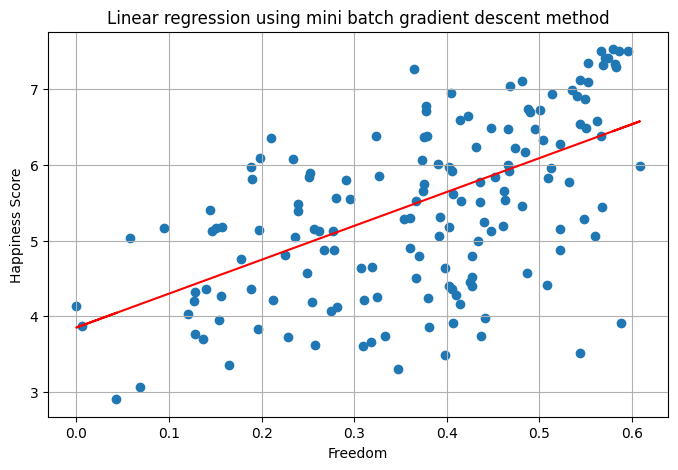

In [35]:
from mini_batch_gd import Linear_Regression_Mini_Batch

X = df['Freedom'].to_numpy()
y = df['Happiness Score'].to_numpy()

mini_batch = Linear_Regression_Mini_Batch()
mini_batch.fit(X, y, max_iters=100, lr=0.3, stats=True)

y_pred = mini_batch.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Mini batch gradient descent')
plt.grid()
plt.xlabel('Freedom')
plt.ylabel('Happiness Score')
plt.title('Linear regression using mini batch gradient descent method')

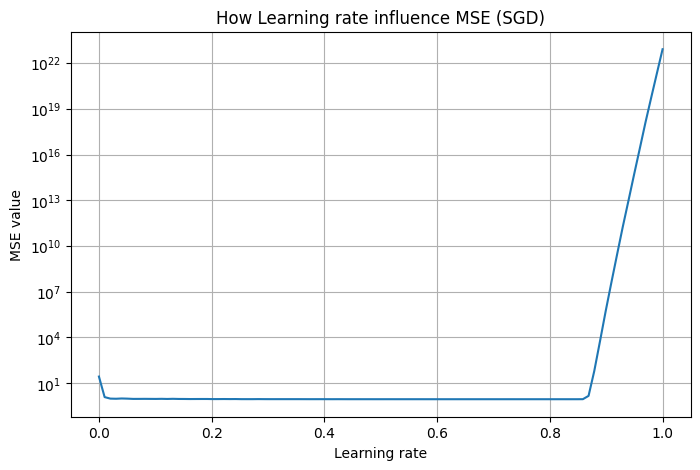

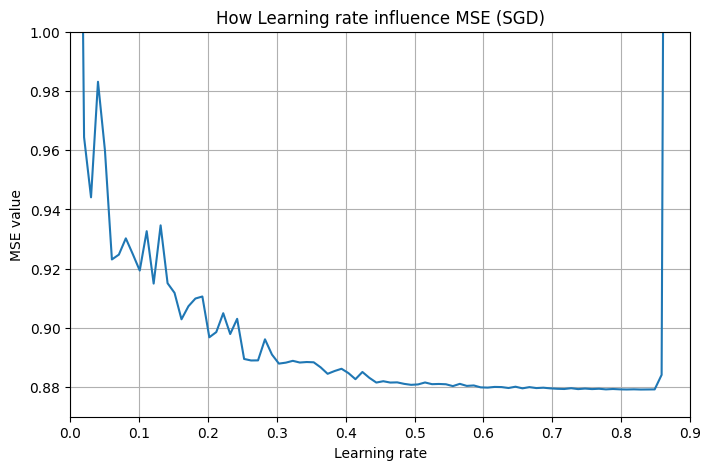

In [41]:
# === Learning rate test ===
learning_rate = np.linspace(0, 1, 100)
errors = []

for alpha in learning_rate:
    lr_test = Linear_Regression_Mini_Batch()
    gradient_descent.fit(X, y, max_iters=100, lr=alpha, stats=False)
    y_pred = gradient_descent.predict(X)

    errors.append(MSE(y, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.yscale('log')
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE (SGD)')
plt.grid()

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.xlim(0, 0.9)
plt.ylim(0.87, 1)
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE (SGD)')
plt.grid()

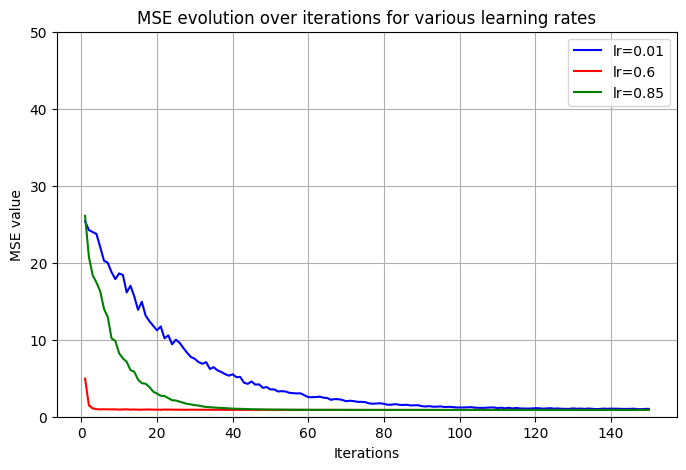

In [52]:
# === Iteration test ===
iterations = np.linspace(1, 150, 150, dtype=int)
learning_rate = [0.01, 0.6, 0.85]

errors = []
for alpha in learning_rate:
    error = []
    for iter in iterations:
        iter_test = Linear_Regression_Mini_Batch()
        gradient_descent.fit(X, y, max_iters=iter, lr=alpha, stats=False)
        y_pred = gradient_descent.predict(X)

        error.append(MSE(y, y_pred))
    errors.append(error)


plt.figure(figsize=(8, 5))
plt.plot(iterations, errors[0], color='blue', label=f'lr={learning_rate[0]}')
plt.plot(iterations, errors[1], color='red', label=f'lr={learning_rate[1]}')
plt.plot(iterations, errors[2], color ='green', label=f'lr={learning_rate[2]}')
plt.ylim(0, 50)
plt.xlabel('Iterations')
plt.ylabel('MSE value')
plt.title('MSE evolution over iterations for various learning rates')
plt.legend()
plt.grid()

---